# Example usage of *libinsitu*

This Notebook demonstrates the basic usage of [libinsitu](https://libinsitu.readthedocs.io/en/latest/), fetching and showing solar irradiance data of a well-formed NetCDF file.

In [1]:
%load_ext autoreload
%autoreload 2

# Prevent verbose logs
%env LOGLEVEL=WARNING

import sys
sys.path.append("..")

from libinsitu import netcdf_to_dataframe, visual_qc
from datetime import datetime
%matplotlib inline

env: LOGLEVEL=WARNING


## Fetch a subset of data over the network (OpenDAP)

The function **netcdf_to_dataframe** loads data from a local or remote (over OpenDAP) NetCDF file and format it to a **pandas Dataframe**, ready to be used.

This function allows to only fetch a subset of variables and time range. Only the requested data is loaded from disk or the network, making it fast.

The full API [is documented here](https://libinsitu.readthedocs.io/en/latest/api.html#libinsitu.common.netcdf_to_dataframe)

In the example below, we get data from the network [NREL MIDC from our Thredds server](http://tds.webservice-energy.org/thredds/catalog/nrelmidc-stations/catalog.html)

The available data on our server is [documented here](https://libinsitu.readthedocs.io/en/latest/data.html).

In [2]:
# Fetch one year of data, for 3 variables
df = netcdf_to_dataframe(
    "http://tds.webservice-energy.org/thredds/dodsC/nrelmidc-stations/NREL_MIDC-BMS.nc",
    start_time=datetime(2020, 1, 1),
    end_time=datetime(2021, 3, 1),
    vars=["GHI", "BNI", "DHI"])

## Metadata

The full metadata is kept in property `attrs` of the Dataframe :

In [3]:
# Shoow first 10 values of meta-data
dict(list(df.attrs.items())[0:10])

{'id': 'NREL_MIDC-BMS',
 'title': 'Timeseries of Measurement and Instrumentation Data Center (MIDC) (NREL_MIDC). Station : NREL Solar Radiation Research Laboratory - Baseline Measurement System',
 'summary': 'Archive of solar radiation networks worldwide provided by the Webservice-Energy initiative supported by MINES Paris PSL. Files are provided as NetCDF file format with the support of a Thredds Data Server.',
 'keywords': 'meteorology, station, time, Earth Science > Atmosphere > Atmospheric Radiation > Incoming Solar Radiation, Earth Science > Atmosphere > Atmospheric Temperature > Surface Temperature > Air Temperature, Earth Science > Atmosphere > Atmospheric Pressure > Sea Level Pressure',
 'keywords_vocabulary': 'GCMD Science Keywords',
 'keywords_vocabulary_url': 'https://gcmd.earthdata.nasa.gov/static/kms/',
 'record': 'Basic measurements (global irradiance, direct irradiance, diffuse irradiance, air temperature, relative humidity, pressure)',
 'featureType': 'timeSeries',
 'cd

## Data

We benefit from the power of the Pandas library. We can explore data, statistics about it.

In [4]:
# Show the data
df.describe()

,BNI,GHI,DHI
count,611581.000000,611581.000000,611581.000000
mean,237.205017,188.849319,62.038319
std,371.820740,283.164764,97.838516
min,-58.437500,-4.812500,-4.812500
25%,-0.437500,-1.125000,-0.687500
50%,0.562500,1.687500,2.187500
75%,513.562500,321.250000,85.750000
max,1078.750000,1438.312500,833.250000


## Plot

We can plot data with a single line of code.

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

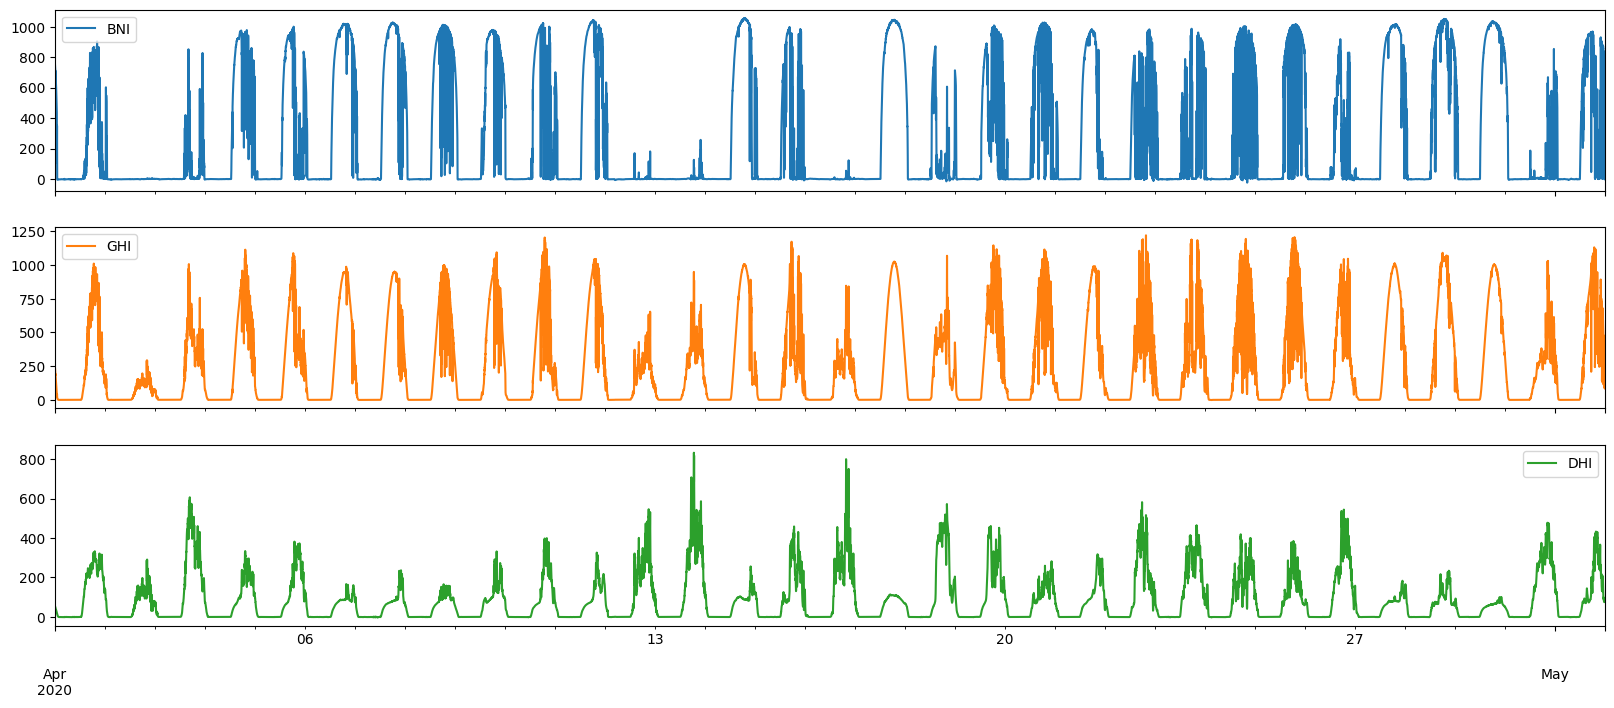

In [5]:
# Show one month of data
df["2020-04-01":"2020-05-01"].plot(figsize=(20, 8), subplots=True)

[10:54:22] ERROR    -:-     Image was not in cache and env var GOOGLE_API_KEY not set

[10:54:22] ERROR    -:-     Image was not in cache and env var GOOGLE_API_KEY not set

[10:54:22] ERROR    -:-     Image was not in cache and env var GOOGLE_API_KEY not set

/home/rjolivet/libinsitu/libinsitu/qc/graphs/base.py:973: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  cbaxes = inset_axes(


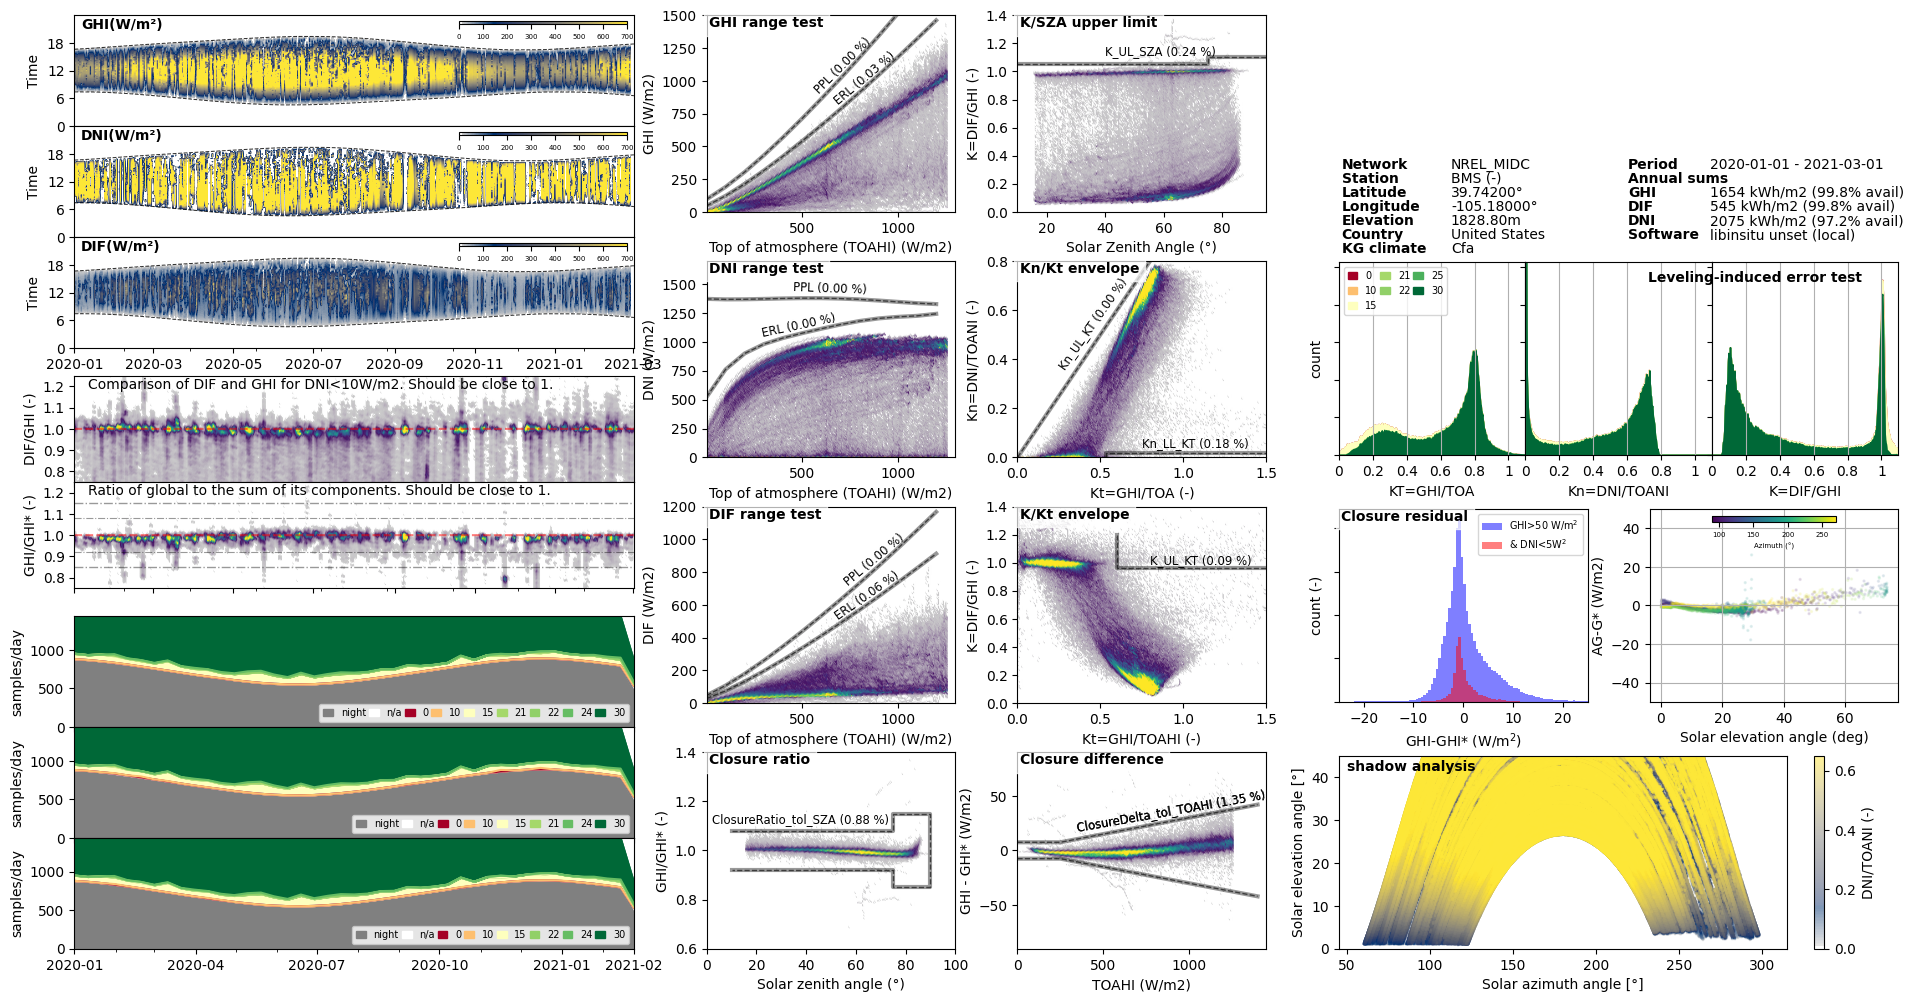

In [3]:
fig = visual_qc(
    df,
    latitude=39.742,
    longitude=-105.18,
    elevation=1828.8)